In [1]:
# Automatically locate the project's root directory
from crispdm.common.path_service_common import find_project_root

# Data manipulation and analysis using DataFrames
import pandas as pd

# Statistical data visualization built on top of matplotlib
import seaborn as sns

# Parsing and handling JSON data structures
import json

# Creating static, animated, and interactive visualizations
import matplotlib.pyplot as plt

# Numerical computing and support for large, multi-dimensional arrays
import numpy as np

# Fitting and working with statistical distributions (Normal, Skew-Normal, Gamma)
from scipy.stats import norm, skewnorm, gamma

# Object-oriented file system paths management
import pathlib

from IPython.display import display

# Reading and writing YAML configuration files
import yaml

In [3]:
# 1. Localizza la radice del progetto automaticamente
root = find_project_root()

# 2. Definisci il percorso verso la cartella di output (la base dei 'runs')
# l'ultima esecuzione o una specifica
run_id = "20260521_095921" # O l'ID che sto analizzando
base_run_dir = root / "outputs" / "runs" / "clustering" / "ms_sec_inc_pre" / run_id

# Definire il percorso di "base fase" per evitare hardcode in tutto il notebook
base_phase_path = base_run_dir / "phase4_data_modeling"

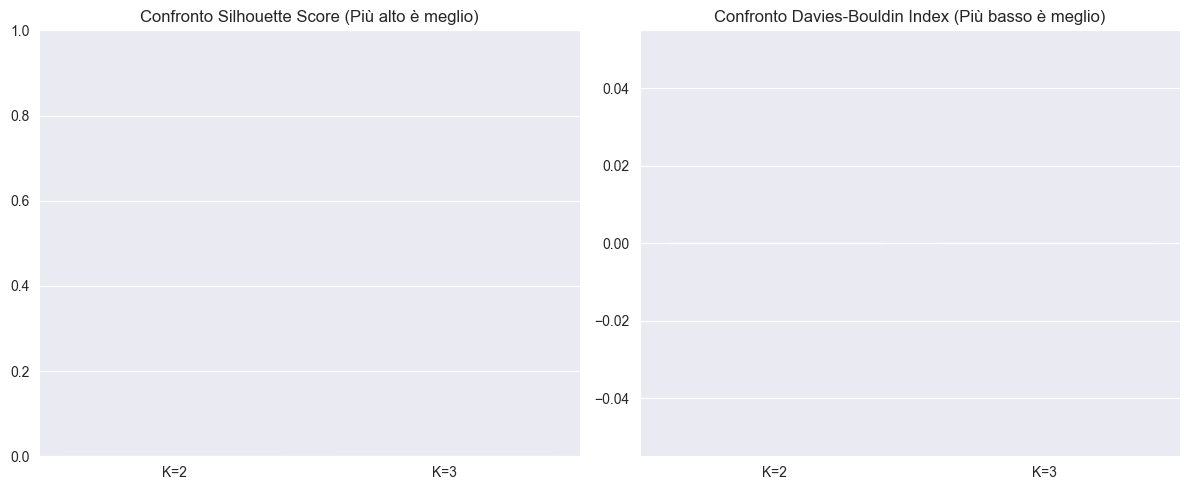

RELAZIONE FASE 4: VALUTAZIONE MODELLI DI CLUSTERING


,Metric,K=2,K=3
0,Silhouette Score (↑ Meglio),0,0
1,Davies-Bouldin (↓ Meglio),0,0



Analisi Architetturale:
Basato sulla separazione matematica e sulla compattezza dei cluster, il modello K-Means con K=3 offre le prestazioni migliori.
La formula della Silhouette evidenzia la coesione intra-cluster contro la separazione inter-cluster.


In [5]:
# =============================================================================
# DEFINIZIONE PERCORSO FASE
# =============================================================================


# =============================================================================
# 1. FASE DI INPUT: Quando entra l'input
# =============================================================================
path_sil_n2 = base_phase_path / "4.5.model_evaluation.silhouette.kmeans_n2.json"
path_sil_n3 = base_phase_path / "4.5.model_evaluation.silhouette.kmeans_n3.json"
path_db_n2 = base_phase_path / "4.5.model_evaluation.davies_bouldin.kmeans_n2.json"
path_db_n3 = base_phase_path / "4.5.model_evaluation.davies_bouldin.kmeans_n3.json"

def load_metric(path):
    with open(path, 'r', encoding='utf-8') as f: return json.load(f)

sil_n2 = load_metric(path_sil_n2)
sil_n3 = load_metric(path_sil_n3)
db_n2 = load_metric(path_db_n2)
db_n3 = load_metric(path_db_n3)

# =============================================================================
# 2. FASE DI LOGICA: Elaborazione e trasformazione dei dati
# =============================================================================
# Costruiamo un DataFrame per confrontare agevolmente K=2 e K=3
comparison_df = pd.DataFrame({
    'Metric': ['Silhouette Score (↑ Meglio)', 'Davies-Bouldin (↓ Meglio)'],
    'K=2': [sil_n2.get('silhouette_score', 0), db_n2.get('davies_bouldin_score', 0)],
    'K=3': [sil_n3.get('silhouette_score', 0), db_n3.get('davies_bouldin_score', 0)]
})
# =============================================================================
# 3. FASE DI DISEGNO: Visualizzazione grafica
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Etichette per l'asse X e per il parametro hue
x_labels = ['K=2', 'K=3']

# Grafico Silhouette
sns.barplot(
    x=x_labels,
    y=[comparison_df.iloc[0]['K=2'], comparison_df.iloc[0]['K=3']],
    ax=axes[0],
    hue=x_labels,           # <--- Correzione per le nuove versioni di Seaborn
    palette="Blues",
    legend=False            # <--- Disattiva la legenda automatica
)
axes[0].set_title("Confronto Silhouette Score (Più alto è meglio)")
axes[0].set_ylim(0, 1)

# Grafico Davies-Bouldin
sns.barplot(
    x=x_labels,
    y=[comparison_df.iloc[1]['K=2'], comparison_df.iloc[1]['K=3']],
    ax=axes[1],
    hue=x_labels,           # <--- Correzione per le nuove versioni di Seaborn
    palette="Oranges",
    legend=False            # <--- Disattiva la legenda automatica
)
axes[1].set_title("Confronto Davies-Bouldin Index (Più basso è meglio)")

plt.tight_layout()
plt.show()
# =============================================================================
# 4. ANALISI FINALE (Stampa per la presentazione al professore)
# =============================================================================
print("=========================================================================")
print("RELAZIONE FASE 4: VALUTAZIONE MODELLI DI CLUSTERING")
print("=========================================================================")
display(comparison_df)

# Determina il vincitore basato sulla Silhouette
best_k = 2 if comparison_df.iloc[0]['K=2'] > comparison_df.iloc[0]['K=3'] else 3
print(f"\nAnalisi Architetturale:")
print(f"Basato sulla separazione matematica e sulla compattezza dei cluster, il modello K-Means con K={best_k} offre le prestazioni migliori.")
print("La formula della Silhouette evidenzia la coesione intra-cluster contro la separazione inter-cluster.")
print("=========================================================================")